# Hard Fair MCA, Soft Fair MCA, and PCA Baselines on Synthetic Biased Data

This notebook creates a synthetic categorical dataset with:
- **known latent structure** (clusters)
- **controlled bias level** with respect to a sensitive attribute

Sensitive attribute: **S** (binary group A/B).

Methods compared:
- Classical MCA
- Hard Fair MCA
- Soft Fair MCA
- Indicator PCA
- Fair PCA

In [2]:
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

project_root = Path.cwd()
local_pkg = project_root / "fair_unsupervised_fairness"
metrics_src = local_pkg / "src"
if metrics_src.exists() and str(metrics_src) not in sys.path:
    sys.path.insert(0, str(metrics_src))

try:
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-e", str(local_pkg)])
    from fair_repr_eval.metrics import (
        adversarial_leakage_score,
        groupwise_mmd,
        percentage_variance_retained,
    )

sns.set_theme(style="whitegrid")

## 1) Generate Synthetic Dataset (Known Structure + Controlled Bias)

Data shape: (1000, 10)
Sensitive groups: {'B': 0.505, 'A': 0.495}
Cluster proportions: {0: 0.461, 1: 0.323, 2: 0.216}


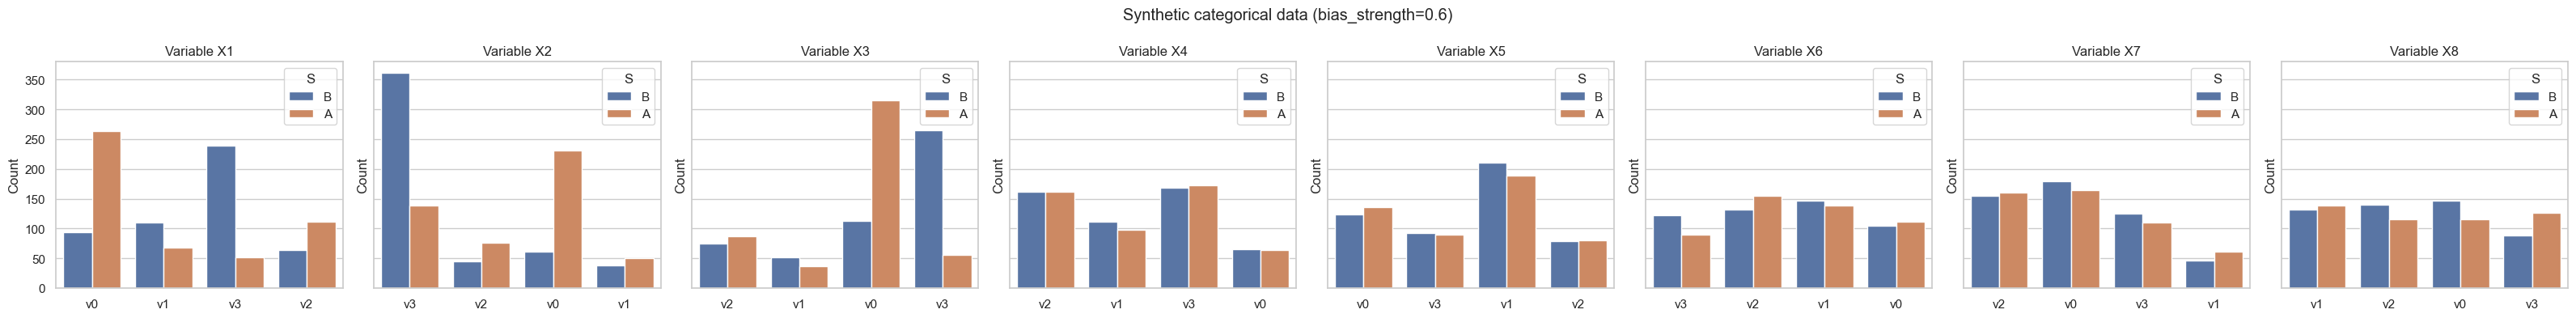

In [50]:
def sample_categorical(prob, rng):
    return rng.choice(len(prob), p=prob)


def generate_synthetic_data(
    n=1000,
    d=8,
    q=4,
    n_clusters=3,
    bias_strength=0.5,
    seed=42,
):
    """
    Generate categorical data with known cluster structure and controlled sensitive bias.

    - cluster C drives most variables (known structure)
    - sensitive S perturbs selected variables with intensity bias_strength in [0, 1]
    """
    rng = np.random.default_rng(seed)

    # Latent structure
    pi_c = np.array([0.45, 0.35, 0.20])[:n_clusters]
    pi_c = pi_c / pi_c.sum()
    C = rng.choice(n_clusters, size=n, p=pi_c)

    # Sensitive attribute (binary)
    S = rng.binomial(1, 0.5, size=n)

    # Base cluster-dependent distributions for each variable
    base = np.zeros((d, n_clusters, q))
    for j in range(d):
        for c in range(n_clusters):
            alpha = np.ones(q) + 2.0 * rng.random(q)
            base[j, c] = rng.dirichlet(alpha)

    # Sensitive-group-specific distributions for biased variables
    sens = np.zeros((d, 2, q))
    for j in range(d):
        sens[j, 0] = rng.dirichlet(np.array([5, 1, 1, 1]))
        sens[j, 1] = rng.dirichlet(np.array([1, 1, 1, 5]))

    biased_vars = set([0, 1, 2])  # first variables carry controllable sensitive bias

    X = np.empty((n, d), dtype=int)
    for i in range(n):
        c = C[i]
        s = S[i]
        for j in range(d):
            p_base = base[j, c]
            if j in biased_vars:
                p = (1.0 - bias_strength) * p_base + bias_strength * sens[j, s]
            else:
                p = p_base
            p = p / p.sum()
            X[i, j] = sample_categorical(p, rng)

    df = pd.DataFrame({f"X{j+1}": [f"v{val}" for val in X[:, j]] for j in range(d)})
    df["S"] = np.where(S == 1, "B", "A")
    df["cluster"] = C
    return df


bias_strength = 0.6
df = generate_synthetic_data(bias_strength=bias_strength, seed=1)

print("Data shape:", df.shape)
print("Sensitive groups:", df["S"].value_counts(normalize=True).to_dict())
print("Cluster proportions:", df["cluster"].value_counts(normalize=True).sort_index().to_dict())


# Categorical data plotting function
def plot_categorical_data(df, title="Synthetic categorical data"):
    d = df.shape[1] - 2  # exclude S and cluster
    fig, axes = plt.subplots(1, d, figsize=(4 * d, 4), sharey=True)
    for j in range(d):
        col = f"X{j+1}"
        sns.countplot(data=df, x=col, hue="S", ax=axes[j])
        axes[j].set_title(f"Variable {col}")
        axes[j].set_xlabel("")
        axes[j].set_ylabel("Count")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


plot_categorical_data(df, title=f"Synthetic categorical data (bias_strength={bias_strength})")

## 2) Build Indicator Matrix for MCA

In [44]:
feature_cols = [c for c in df.columns if c.startswith("X")]
X_cat = df[feature_cols].astype(str).copy()
X_disj = pd.get_dummies(X_cat, prefix_sep="=", dtype=float)

N = X_disj.values  # n x m indicator matrix
n, m = N.shape

# Sensitive attribute as binary indicator
g = (df["S"].values == "B").astype(float)

print("Feature count:", len(feature_cols))
print("Disjunctive table shape (n, m):", N.shape)

Feature count: 8
Disjunctive table shape (n, m): (1000, 32)


## 3) MCA Utilities + Fairness Utilities

In [5]:
def inv_sqrt_diag(x, eps=1e-12):
    return np.diag(1.0 / np.sqrt(np.maximum(x, eps)))


def standardized_residuals_from_indicator(N, eps=1e-12):
    N = np.asarray(N, dtype=float)
    P = N / N.sum()
    r = P.sum(axis=1)
    c = P.sum(axis=0)
    Dr_inv_sqrt = inv_sqrt_diag(r, eps)
    Dc_inv_sqrt = inv_sqrt_diag(c, eps)
    S = Dr_inv_sqrt @ (P - np.outer(r, c)) @ Dc_inv_sqrt
    return S, r, c, Dr_inv_sqrt, Dc_inv_sqrt


def classical_mca(N, k=10, eps=1e-12):
    S, r, c, Dr_inv_sqrt, Dc_inv_sqrt = standardized_residuals_from_indicator(N, eps)
    U, s, Vt = np.linalg.svd(S, full_matrices=False)
    k = min(k, len(s))
    U = U[:, :k]
    V = Vt.T[:, :k]
    s = s[:k]

    F = Dr_inv_sqrt @ U @ np.diag(s)
    G = Dc_inv_sqrt @ V @ np.diag(s)

    return {
        "S": S, "r": r, "c": c,
        "Dr_inv_sqrt": Dr_inv_sqrt, "Dc_inv_sqrt": Dc_inv_sqrt,
        "U": U, "V": V, "singular_values": s,
        "eigenvalues": s**2, "F": F, "G": G
    }


def indicator_pca(N, k=10):
    N = np.asarray(N, dtype=float)
    pca = PCA(n_components=min(k, min(N.shape)), whiten=True)
    F = pca.fit_transform(N)

    return {
        "F": F[:, :k],
        "eigenvalues": pca.explained_variance_[:k],
        "explained_variance_ratio": pca.explained_variance_ratio_[:k],
    }


def make_Z_column_space(N, g_binary, eps=1e-12):
    # Group indicators in row space: n x 2 (A, B)
    G_ind = np.column_stack([1.0 - g_binary, g_binary])

    # Map to column/modalities space: m x 2
    Z = N.T @ G_ind

    # Normalize each modality row
    Z = Z / np.maximum(Z.sum(axis=1, keepdims=True), eps)
    return Z


def hard_fair_mca(N, Z, k=10, eps=1e-12):
    S, r, c, Dr_inv_sqrt, Dc_inv_sqrt = standardized_residuals_from_indicator(N, eps)
    A_Z = Dr_inv_sqrt @ S @ Z  # n x s

    PZ = np.eye(S.shape[0]) - A_Z @ np.linalg.pinv(A_Z.T @ A_Z) @ A_Z.T
    S_fair = PZ @ S

    U, s, Vt = np.linalg.svd(S_fair, full_matrices=False)
    k = min(k, len(s))
    U = U[:, :k]
    V = Vt.T[:, :k]
    s = s[:k]

    F = Dr_inv_sqrt @ U @ np.diag(s)
    G = Dc_inv_sqrt @ V @ np.diag(s)

    return {
        "S": S_fair, "A_Z": A_Z, "PZ": PZ,
        "eigenvalues": s**2, "F": F, "G": G
    }


def soft_fair_mca(N, Z, k=10, lambda_fair=10.0, eps=1e-12):
    S, r, c, Dr_inv_sqrt, Dc_inv_sqrt = standardized_residuals_from_indicator(N, eps)
    A_Z = Dr_inv_sqrt @ S @ Z  # n x s

    B = S @ S.T - lambda_fair * (A_Z @ A_Z.T)
    evals, evecs = np.linalg.eigh(B)
    idx = np.argsort(evals)[::-1]
    evals = evals[idx]
    evecs = evecs[:, idx]

    pos = evals > eps
    evals = evals[pos]
    evecs = evecs[:, pos]

    k = min(k, len(evals))
    mu = evals[:k]
    U = evecs[:, :k]

    F = Dr_inv_sqrt @ U @ np.diag(np.sqrt(mu))

    denom = np.sqrt(np.maximum(mu, eps))
    V = (S.T @ U) / denom[np.newaxis, :]
    G = Dc_inv_sqrt @ V @ np.diag(np.sqrt(mu))

    return {
        "S": S, "A_Z": A_Z, "B": B,
        "eigenvalues": mu, "F": F, "G": G
    }


def fair_pca(N, Z, k=10):
    N = np.asarray(N, dtype=float)
    Z = np.asarray(Z, dtype=float)

    A_Z = N @ Z
    PZ = np.eye(N.shape[0]) - A_Z @ np.linalg.pinv(A_Z.T @ A_Z) @ A_Z.T
    N_fair = PZ @ N

    pca = PCA(n_components=min(k, min(N_fair.shape)))
    F = pca.fit_transform(N_fair)

    return {
        "F": F[:, :k],
        "eigenvalues": pca.explained_variance_[:k],
        "explained_variance_ratio": pca.explained_variance_ratio_[:k],
    }


def safe_corr(x, y, eps=1e-12):
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    x = x - x.mean()
    y = y - y.mean()
    den = np.sqrt((x @ x) * (y @ y))
    if den < eps:
        return 0.0
    return float((x @ y) / den)


def component_sensitive_corr(F, g):
    return np.array([safe_corr(F[:, j], g) for j in range(F.shape[1])])

## 4) Run Classical, Hard Fair, and Soft Fair MCA

In [10]:
k = 5
lambda_fair = 0.001


Z = make_Z_column_space(N, g)

res_classic = classical_mca(N, k=k)
res_hard = hard_fair_mca(N, Z=Z, k=k)
res_soft = soft_fair_mca(N, Z=Z, k=k, lambda_fair=lambda_fair)
res_pca = indicator_pca(N, k=k)
res_fpca = fair_pca(N, Z=Z, k=k)

corr_classic = component_sensitive_corr(res_classic["F"], g)
corr_hard = component_sensitive_corr(res_hard["F"], g)
corr_soft = component_sensitive_corr(res_soft["F"], g)
corr_pca = component_sensitive_corr(res_pca["F"], g)
corr_fpca = component_sensitive_corr(res_fpca["F"], g)

print("Classical MCA - Mean Absolute Correlation with Gender:", np.mean(np.abs(corr_classic)))
print("Hard Fair MCA - Mean Absolute Correlation with Gender:", np.mean(np.abs(corr_hard)))
print("Soft Fair MCA - Mean Absolute Correlation with Gender:", np.mean(np.abs(corr_soft)))
print("Indicator-Matrix PCA - Mean Absolute Correlation with Gender:", np.mean(np.abs(corr_pca)))
print("Fair PCA - Mean Absolute Correlation with Gender:", np.mean(np.abs(corr_fpca)))

summary = pd.DataFrame({
    "component": np.arange(1, k + 1),
    "eig_classic": np.pad(res_classic["eigenvalues"], (0, max(0, k - len(res_classic["eigenvalues"]))))[:k],
    "eig_hard": np.pad(res_hard["eigenvalues"], (0, max(0, k - len(res_hard["eigenvalues"]))))[:k],
    "eig_soft": np.pad(res_soft["eigenvalues"], (0, max(0, k - len(res_soft["eigenvalues"]))))[:k],
    "eig_pca": np.pad(res_pca["eigenvalues"], (0, max(0, k - len(res_pca["eigenvalues"]))))[:k],
    "eig_fpca": np.pad(res_fpca["eigenvalues"], (0, max(0, k - len(res_fpca["eigenvalues"]))))[:k],
    "corr_classic": np.pad(corr_classic, (0, max(0, k - len(corr_classic))))[:k],
    "corr_hard": np.pad(corr_hard, (0, max(0, k - len(corr_hard))))[:k],
    "corr_soft": np.pad(corr_soft, (0, max(0, k - len(corr_soft))))[:k],
    "corr_pca": np.pad(corr_pca, (0, max(0, k - len(corr_pca))))[:k],
    "corr_fpca": np.pad(corr_fpca, (0, max(0, k - len(corr_fpca))))[:k],
})

method_embeddings = {
    "classic": res_classic["F"],
    "hard": res_hard["F"],
    "soft": res_soft["F"],
    "pca": res_pca["F"],
    "fair_pca": res_fpca["F"],
}
metric_rows = []
for method, emb in method_embeddings.items():
    mmd = groupwise_mmd(emb, g)
    adv = adversarial_leakage_score(emb, g)
    metric_rows.append({
        "method": method,
        "variance_retained_percent": percentage_variance_retained(N, emb),
        "rho_mean": np.mean(np.abs(component_sensitive_corr(emb, g))),
        "mmd_mean": mmd["mean"],
        "adversarial_accuracy_mean": adv["accuracy_mean"],
        "adversarial_majority_class_baseline": adv["majority_class_baseline"],
        "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
    })

fair_metrics = pd.DataFrame(metric_rows).sort_values("method").reset_index(drop=True)

fair_metrics

Classical MCA - Mean Absolute Correlation with Gender: 0.20217282777883047
Hard Fair MCA - Mean Absolute Correlation with Gender: 0.024467928432077304
Soft Fair MCA - Mean Absolute Correlation with Gender: 0.03750514248723192
Indicator-Matrix PCA - Mean Absolute Correlation with Gender: 0.18175970522841317
Fair PCA - Mean Absolute Correlation with Gender: 0.013038415399082653


,method,variance_retained_percent,rho_mean,mmd_mean,adversarial_accuracy_mean,adversarial_majority_class_baseline,deltaAccuracy
0,classic,30.074904,0.202173,0.202486,0.892,0.505,0.387
1,fair_pca,24.676403,0.013038,0.000000,0.478,0.505,0.027
2,hard,24.404336,0.024468,0.000964,0.522,0.505,0.017
3,pca,29.800322,0.181760,0.151209,0.872,0.505,0.367
4,soft,24.894157,0.037505,0.002665,0.550,0.505,0.045


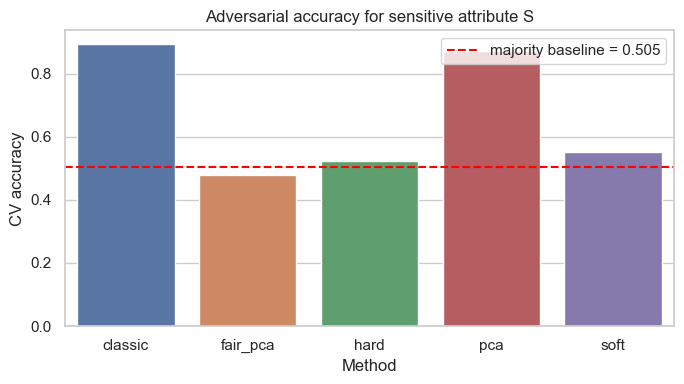

In [12]:
adv_df = fair_metrics[[
    "method",
    "adversarial_accuracy_mean",
    "adversarial_majority_class_baseline",
]].copy()
adv_df

plt.figure(figsize=(7, 4))
sns.barplot(data=adv_df, x="method", y="adversarial_accuracy_mean")
baseline = float(adv_df["adversarial_majority_class_baseline"].iloc[0])
plt.axhline(baseline, color="red", linestyle="--", label=f"majority baseline = {baseline:.3f}")
plt.title("Adversarial accuracy for sensitive attribute S")
plt.ylabel("CV accuracy")
plt.xlabel("Method")
plt.legend()
plt.tight_layout()
plt.show()

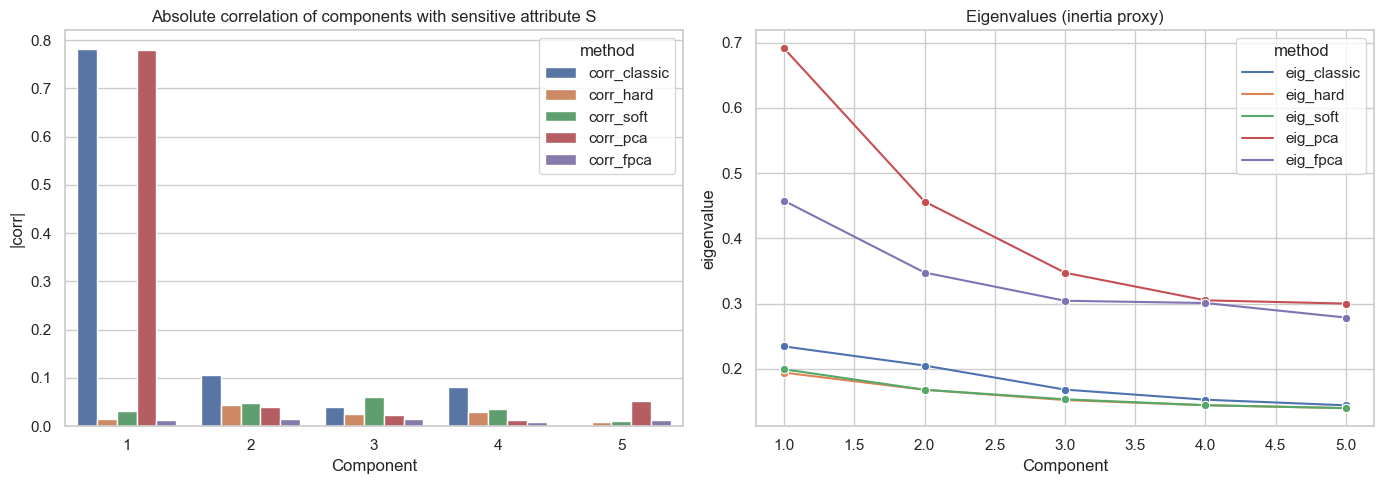

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = pd.melt(
    summary[["component", "corr_classic", "corr_hard", "corr_soft", "corr_pca", "corr_fpca"]],
    id_vars=["component"],
    var_name="method",
    value_name="corr"
 )
plot_df["abs_corr"] = np.abs(plot_df["corr"])
sns.barplot(data=plot_df, x="component", y="abs_corr", hue="method", ax=axes[0])
axes[0].set_title("Absolute correlation of components with sensitive attribute S")
axes[0].set_ylabel("|corr|")
axes[0].set_xlabel("Component")

eig_df = pd.melt(
    summary[["component", "eig_classic", "eig_hard", "eig_soft", "eig_pca", "eig_fpca"]],
    id_vars=["component"],
    var_name="method",
    value_name="eigenvalue"
 )
sns.lineplot(data=eig_df, x="component", y="eigenvalue", hue="method", marker="o", ax=axes[1])
axes[1].set_title("Eigenvalues (inertia proxy)")
axes[1].set_xlabel("Component")

plt.tight_layout()
plt.show()

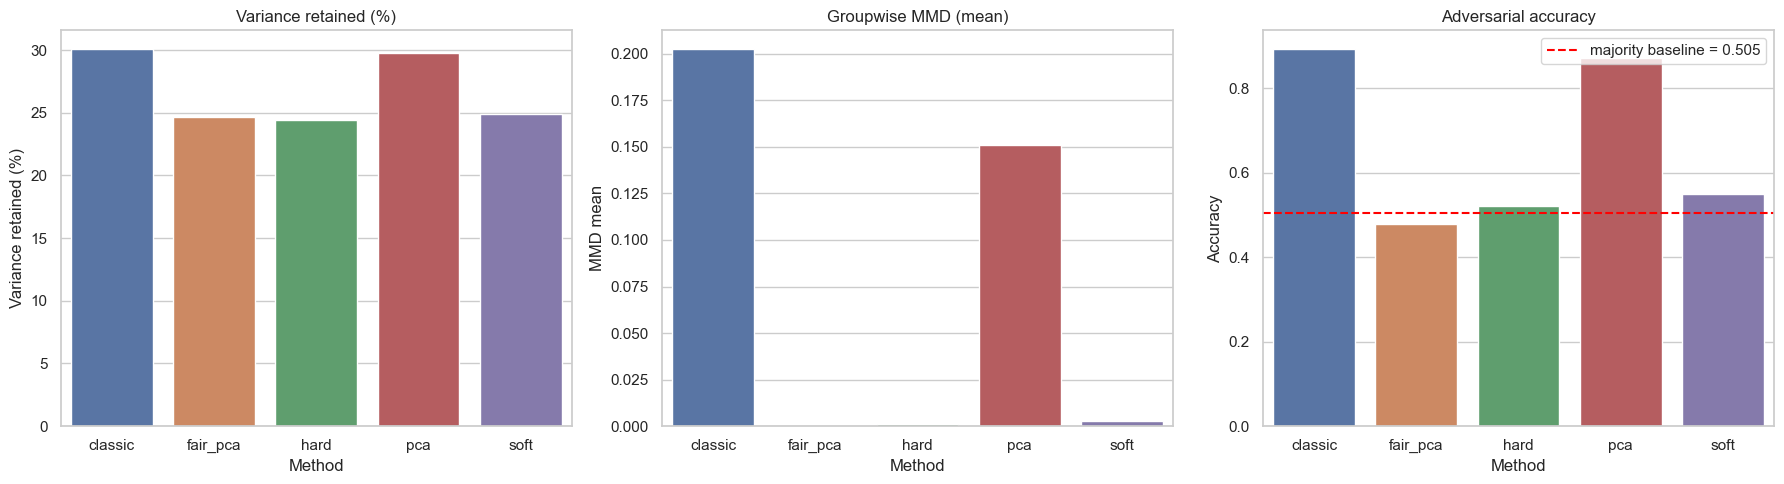

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=fair_metrics, x="method", y="variance_retained_percent", ax=axes[0])
axes[0].set_title("Variance retained (%)")
axes[0].set_ylabel("Variance retained (%)")
axes[0].set_xlabel("Method")

sns.barplot(data=fair_metrics, x="method", y="mmd_mean", ax=axes[1])
axes[1].set_title("Groupwise MMD (mean)")
axes[1].set_ylabel("MMD mean")
axes[1].set_xlabel("Method")

sns.barplot(data=fair_metrics, x="method", y="adversarial_accuracy_mean", ax=axes[2])
baseline = float(fair_metrics["adversarial_majority_class_baseline"].iloc[0])
axes[2].axhline(baseline, color="red", linestyle="--", label=f"majority baseline = {baseline:.3f}")
axes[2].set_title("Adversarial accuracy")
axes[2].set_ylabel("Accuracy")
axes[2].set_xlabel("Method")
axes[2].legend()

plt.tight_layout()
plt.show()

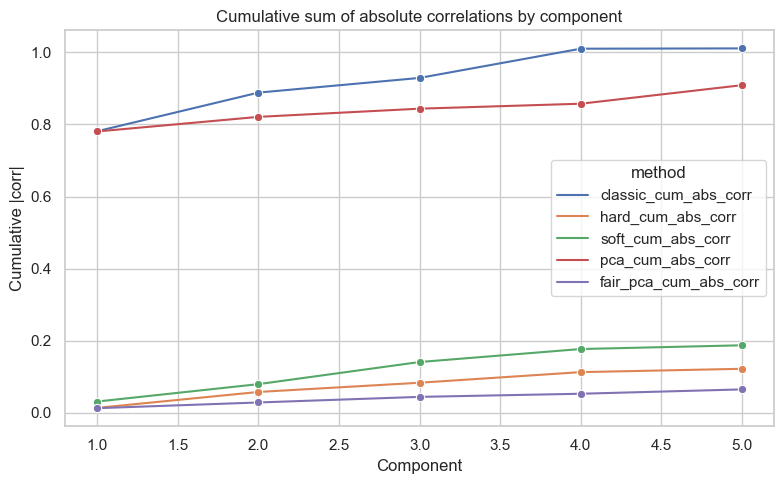

,component,classic_cum_abs_corr,hard_cum_abs_corr,soft_cum_abs_corr,pca_cum_abs_corr,fair_pca_cum_abs_corr
0,1,0.781230,0.013978,0.031601,0.780513,0.013127
1,2,0.888250,0.058088,0.079791,0.820991,0.028954
2,3,0.928981,0.083699,0.141133,0.843706,0.044478
3,4,1.010047,0.113088,0.177164,0.857441,0.053154
4,5,1.010864,0.122340,0.187526,0.908799,0.065192


In [16]:
# Cumulative sum of absolute correlations across components
cum_df = pd.DataFrame({
    "component": summary["component"],
    "classic_cum_abs_corr": np.cumsum(np.abs(summary["corr_classic"])),
    "hard_cum_abs_corr": np.cumsum(np.abs(summary["corr_hard"])),
    "soft_cum_abs_corr": np.cumsum(np.abs(summary["corr_soft"])),
    "pca_cum_abs_corr": np.cumsum(np.abs(summary["corr_pca"])),
    "fair_pca_cum_abs_corr": np.cumsum(np.abs(summary["corr_fpca"])),
})

cum_plot = pd.melt(
    cum_df,
    id_vars=["component"],
    var_name="method",
    value_name="cum_abs_corr",
)

plt.figure(figsize=(8, 5))
sns.lineplot(data=cum_plot, x="component", y="cum_abs_corr", hue="method", marker="o")
plt.title("Cumulative sum of absolute correlations by component")
plt.xlabel("Component")
plt.ylabel("Cumulative |corr|")
plt.tight_layout()
plt.show()

cum_df

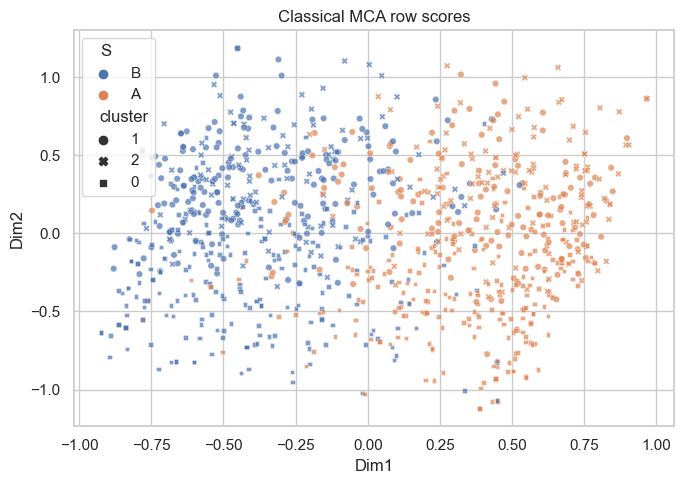

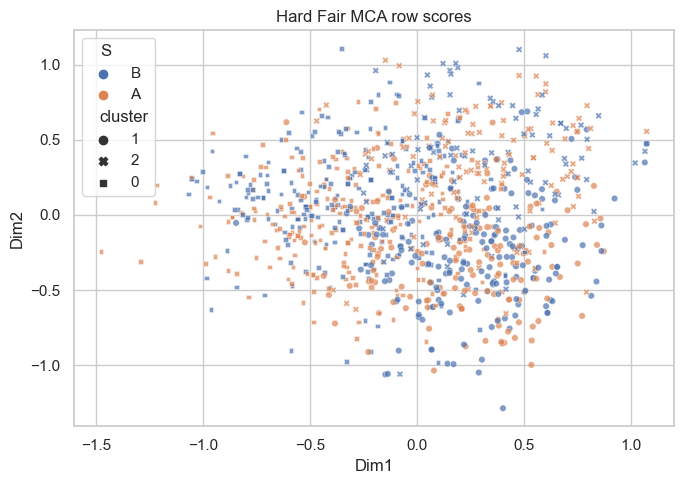

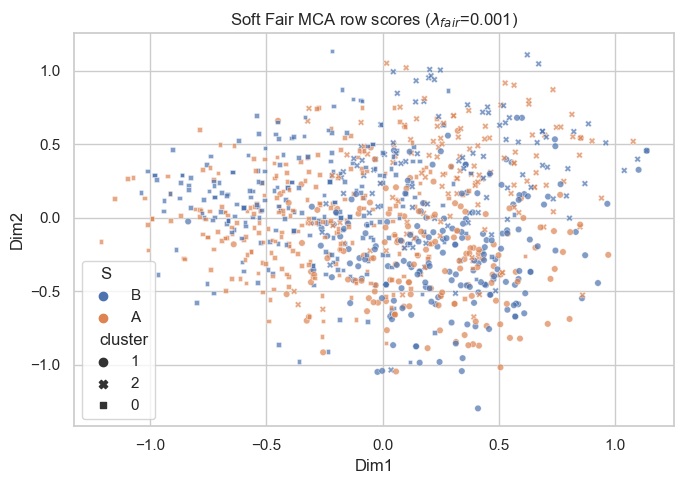

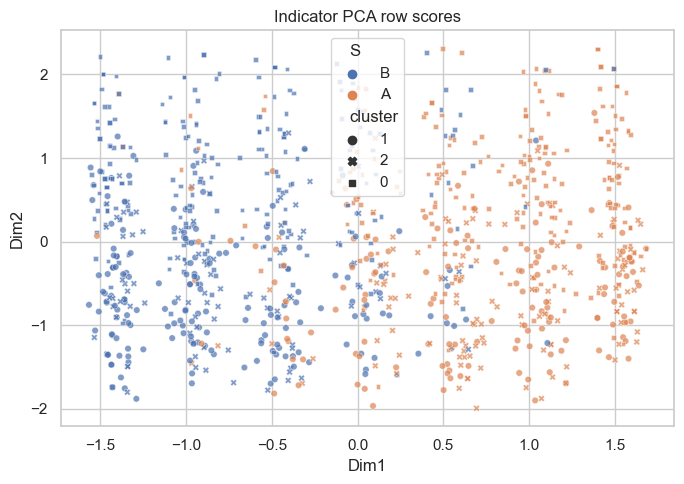

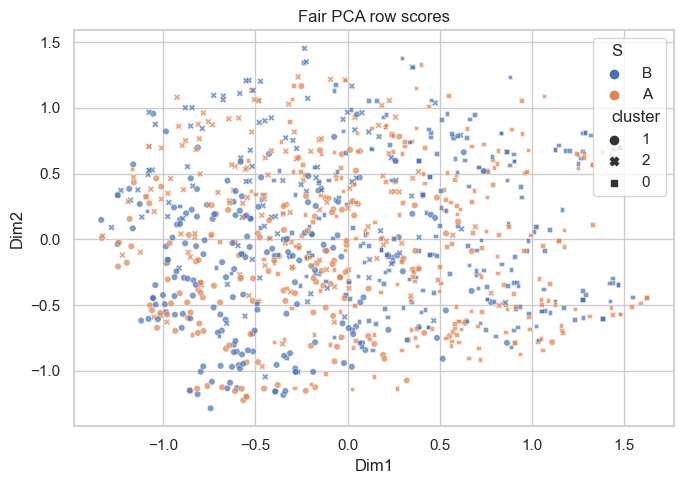

In [52]:
def scatter_scores(F, sensitive, cluster, title):
    dfp = pd.DataFrame({
        "Dim1": F[:, 0],
        "Dim2": F[:, 1],
        "S": sensitive,
        "cluster": cluster.astype(str)
    })
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=dfp, x="Dim1", y="Dim2", hue="S", style="cluster", alpha=0.7, s=22)
    plt.title(title)
    plt.tight_layout()
    plt.show()

scatter_scores(res_classic["F"], df["S"].values, df["cluster"].values, "Classical MCA row scores")
scatter_scores(res_hard["F"], df["S"].values, df["cluster"].values, "Hard Fair MCA row scores")
scatter_scores(res_soft["F"], df["S"].values, df["cluster"].values, f"Soft Fair MCA row scores ($\lambda_{{fair}}$={lambda_fair})")
scatter_scores(res_pca["F"], df["S"].values, df["cluster"].values, "Indicator PCA row scores")
scatter_scores(res_fpca["F"], df["S"].values, df["cluster"].values, "Fair PCA row scores")

## 5) Controlled Bias Sweep

In [23]:
def evaluate_methods_for_bias(bias_values, n_runs=1, k=5, lambda_fair=0.001):
    rows = []
    for b in bias_values:
        for run in range(n_runs):
            dfi = generate_synthetic_data(bias_strength=b, seed=100 + run)
            Xi = dfi[[c for c in dfi.columns if c.startswith("X")]].astype(str)
            Ni = pd.get_dummies(Xi, prefix_sep="=", dtype=float).values
            sensitive_i = dfi["S"].astype(str).values
            gi = (dfi["S"].values == "B").astype(float)
            Zi = make_Z_column_space(Ni, gi)

            rc = classical_mca(Ni, k=k)
            rh = hard_fair_mca(Ni, Zi, k=k)
            rs = soft_fair_mca(Ni, Zi, k=k, lambda_fair=lambda_fair)
            rp = indicator_pca(Ni, k=k)
            rfp = fair_pca(Ni, Z=Zi, k=k)

            for name, rr in [("classic", rc), ("hard", rh), ("soft", rs)]:
                corr = component_sensitive_corr(rr["F"], gi)
                mmd = groupwise_mmd(rr["F"], sensitive_i)
                adv = adversarial_leakage_score(rr["F"], sensitive_i)
                rows.append({
                    "bias_strength": b,
                    "run": run,
                    "method": name,
                    "mean_abs_corr": float(np.mean(np.abs(corr))),
                    "sum_eigenvalues": float(np.sum(rr["eigenvalues"])),
                    "variance_retained_percent": percentage_variance_retained(Ni, rr["F"]),
                    "mmd_mean": mmd["mean"],
                    "adv_accuracy": adv["accuracy_mean"],
                    "deltaAccuracy": np.abs(adv["accuracy_mean"] - adv["majority_class_baseline"]),
                })
    return pd.DataFrame(rows)


bias_values = [0.0, 0.2, 0.4, 0.6, 0.8]
sweep = evaluate_methods_for_bias(bias_values, n_runs=1, k=5, lambda_fair=lambda_fair)
sweep.groupby(["bias_strength", "method"], as_index=False).mean(numeric_only=True).head()

,bias_strength,method,run,mean_abs_corr,sum_eigenvalues,variance_retained_percent,mmd_mean,adv_accuracy,deltaAccuracy
0,0.0,classic,0.0,0.019919,0.948759,30.972949,0.000000,0.491,0.023
1,0.0,hard,0.0,0.011925,0.912803,29.770009,0.000000,0.477,0.037
2,0.0,soft,0.0,0.016511,0.941751,30.845310,0.000000,0.477,0.037
3,0.2,classic,0.0,0.027561,0.927487,30.111082,0.000009,0.513,0.001
4,0.2,hard,0.0,0.017554,0.910627,29.476161,0.000000,0.475,0.039


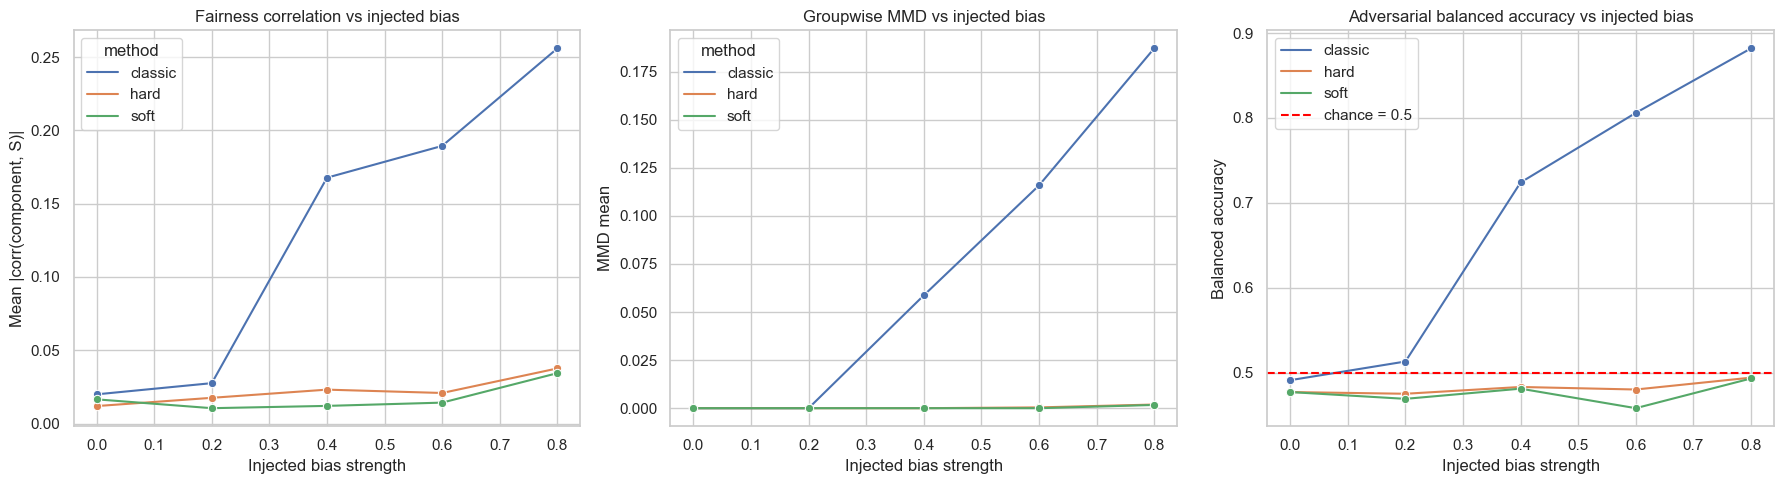

,bias_strength,method,mean_abs_corr,mean_mmd,mean_adv_balanced_accuracy,mean_inertia
0,0.0,classic,0.019919,0.000000,0.491,0.948759
1,0.0,hard,0.011925,0.000000,0.477,0.912803
2,0.0,soft,0.016511,0.000000,0.477,0.941751
3,0.2,classic,0.027561,0.000009,0.513,0.927487
4,0.2,hard,0.017554,0.000000,0.475,0.910627
5,0.2,soft,0.010482,0.000000,0.469,0.921670
6,0.4,classic,0.167718,0.058655,0.724,0.904860
7,0.4,hard,0.023132,0.000000,0.483,0.875603
8,0.4,soft,0.012044,0.000000,0.481,0.883204
9,0.6,classic,0.189407,0.115782,0.806,0.915788


In [24]:
agg = sweep.groupby(["bias_strength", "method"], as_index=False).agg(
    mean_abs_corr=("mean_abs_corr", "mean"),
    mean_mmd=("mmd_mean", "mean"),
    mean_adv_balanced_accuracy=("adv_accuracy", "mean"),
    mean_inertia=("sum_eigenvalues", "mean"),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.lineplot(data=agg, x="bias_strength", y="mean_abs_corr", hue="method", marker="o", ax=axes[0])
axes[0].set_title("Fairness correlation vs injected bias")
axes[0].set_ylabel("Mean |corr(component, S)|")

sns.lineplot(data=agg, x="bias_strength", y="mean_mmd", hue="method", marker="o", ax=axes[1])
axes[1].set_title("Groupwise MMD vs injected bias")
axes[1].set_ylabel("MMD mean")

sns.lineplot(data=agg, x="bias_strength", y="mean_adv_balanced_accuracy", hue="method", marker="o", ax=axes[2])
axes[2].axhline(0.5, color="red", linestyle="--", label="chance = 0.5")
axes[2].set_title("Adversarial balanced accuracy vs injected bias")
axes[2].set_ylabel("Balanced accuracy")
axes[2].legend()

for ax in axes:
    ax.set_xlabel("Injected bias strength")

plt.tight_layout()
plt.show()

agg

## 6) Lambda_fair Sensitivity Study

In [45]:
lambda_grid = np.array([0.0, 1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1])
lambda_rows = []

for lam in lambda_grid:
    res_lam = soft_fair_mca(N, Z=Z, k=k, lambda_fair=float(lam))
    corr_lam = component_sensitive_corr(res_lam["F"], g)
    mmd_lam = groupwise_mmd(res_lam["F"], sensitive_labels)
    adv_lam = adversarial_leakage_score(res_lam["F"], sensitive_labels)
    lambda_rows.append({
        "lambda_fair": float(lam),
        "mean_abs_corr": float(np.mean(np.abs(corr_lam))) if len(corr_lam) else 0.0,
        "sum_eigenvalues": float(np.sum(res_lam["eigenvalues"])),
        "mmd_mean": mmd_lam["mean"],
        "adv_accuracy": adv_lam["accuracy_mean"],
        "variance_retained_percent": percentage_variance_retained(N, res_lam["F"]),
        "deltaAccuracy": np.abs(adv_lam["accuracy_mean"] - adv_lam["majority_class_baseline"]),
    })

lambda_study = pd.DataFrame(lambda_rows)
lambda_study

,lambda_fair,mean_abs_corr,sum_eigenvalues,mmd_mean,adv_accuracy,variance_retained_percent,deltaAccuracy
0,0.00000,0.196998,0.875773,0.117180,0.802,28.598043,0.297
1,0.00001,0.198690,0.872532,0.114979,0.807,28.594199,0.302
2,0.00005,0.210887,0.860150,0.104286,0.795,28.531128,0.290
3,0.00010,0.198268,0.846738,0.083474,0.759,28.211115,0.254
4,0.00050,0.039039,0.823987,0.002043,0.552,25.617074,0.047
5,0.00100,0.021818,0.820955,0.000215,0.508,25.424145,0.003
6,0.00500,0.016523,0.816548,0.000000,0.503,25.142969,0.002
7,0.01000,0.017689,0.815655,0.000000,0.498,25.075017,0.007
8,0.05000,0.018696,0.814840,0.000000,0.503,25.008886,0.002
9,0.10000,0.018827,0.814731,0.000000,0.502,24.999731,0.003


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


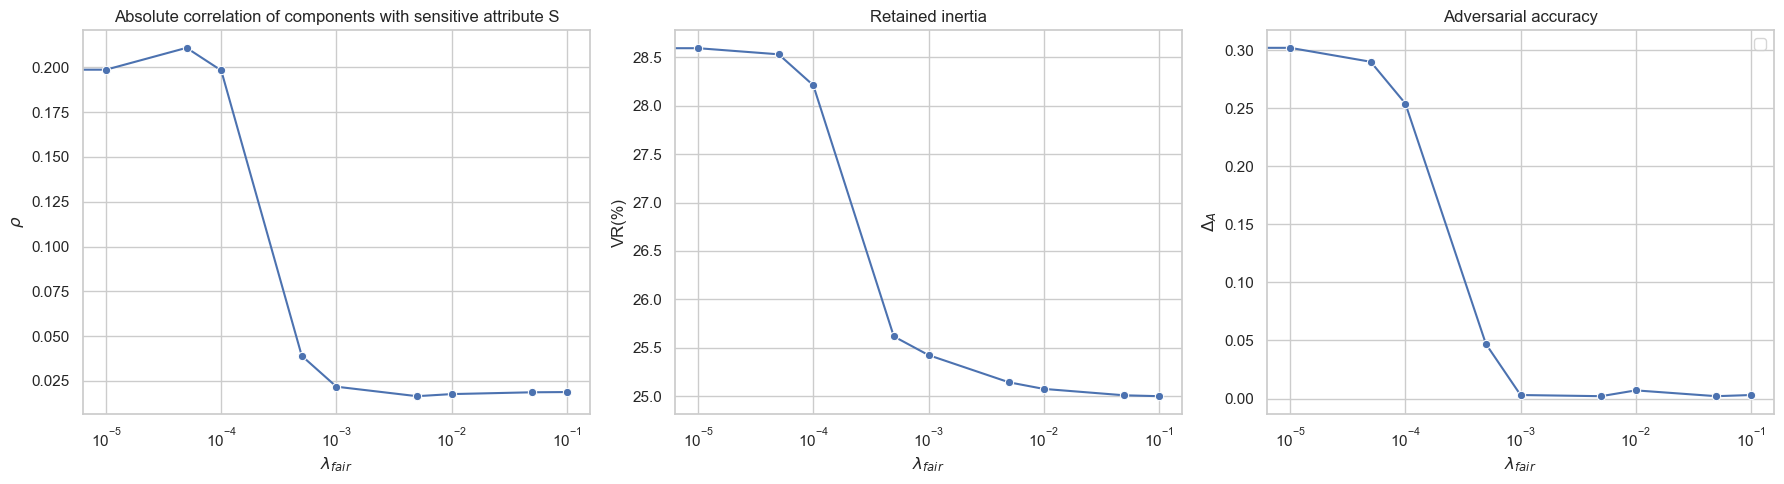

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.lineplot(data=lambda_study, x="lambda_fair", y="mean_abs_corr", marker="o", ax=axes[0])
axes[0].set_xscale("log")
axes[0].set_title("Absolute correlation of components with sensitive attribute S")
axes[0].set_ylabel(r"$\rho$")
axes[0].set_xlabel("$\lambda_{fair}$")

sns.lineplot(data=lambda_study, x="lambda_fair", y="variance_retained_percent", marker="o", ax=axes[1])
axes[1].set_xscale("log")
axes[1].set_title("Retained inertia")
axes[1].set_ylabel("VR(%)")
axes[1].set_xlabel("$\lambda_{fair}$")

sns.lineplot(data=lambda_study, x="lambda_fair", y="deltaAccuracy", marker="o", ax=axes[2])
axes[2].set_xscale("log")
axes[2].set_title("Adversarial accuracy")
axes[2].set_ylabel("$\Delta_A$")
axes[2].set_xlabel("$\lambda_{fair}$")
axes[2].legend()

plt.tight_layout()
plt.show()

## 7) Notes

- The latent cluster variable provides the known structure.
- `bias_strength` controls how strongly selected variables depend on the sensitive attribute.
- Hard Fair MCA usually gives the strongest decorrelation with a larger inertia cost.
- Soft Fair MCA offers a smoother trade-off via $\lambda$.